# Object Detection Demo: „Was ist wo im Bild?“

In dieser Demo gehen wir einen Schritt weiter als bei der Bildklassifikation:
**Objekterkennung (Detection)** sagt nicht nur *was* im Bild ist, sondern auch *wo*.

Wir starten wieder ganz vorne:
1) Bild laden und anschauen
2) Bild-Shape checken (H×W×C)
3) YOLO-Detection-Modell laden (Achtung - das ist nun ein anderes Modell!)
4) Inferenz ausführen und Ergebnisse untersuchen:
   - Wie viele Objekte wurden gefunden?
   - Welche Klassen und Konfidenzen?
   - Wie sehen die Bounding Boxes (Koordinaten) aus?


In [ ]:
# Hier schnell die nötigen Packages installieren...

!pip -q install ultralytics opencv-python matplotlib numpy

## Ein YOLO-Detektionsmodell laden

Wir haben jetzt zwei Bildpfade definiert - einmal für unsere bewährten Katzenfotos, und
einmal für die Fotos mit mehreren Objekten am Bild.

Da wir bereits wissen, dass YOLO auch mit Pfaden umgehen kann, laden wir als nächstes 
gleich unser Detection-Modell!

In [2]:
from ultralytics import YOLO

det_model = YOLO("yolo11s.pt")  # Detection-Modell
det_model

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(96, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_runnin

Wie bereits beim Bildklassifikationsmodell, ist auch hier das Laden eines passenden
vortrainierten Modells schnell erledigt. Ein genauerer Blick auf die Modellarchitektur
zeigt aber, dass dieses Modell bereits um ein vielfaches komplexer (und tiefer) ist, als
das Klassifikationsmodell.

Wir haben:
- 23 Layer-Blöcker, die jeweils aus einer Vielzahl an Convolutional Layers bestehen
- kein einfach verständliches Output-Layer mehr, wie beim Klassifikationsmodell

## Inferenz mit dem Detektionsmodell

Als nächstes wollen wir uns ansehen, wie ein Output des Detektionsmodells aussehen kann -
zunächst für ein einzelnes Katzenfoto.

Image shape (H,W,C): (2475, 3758, 3)


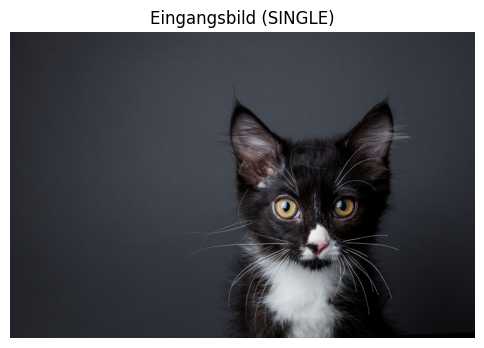

Typ: <class 'list'>
Anzahl Results: 1
Typ eines Elements: <class 'ultralytics.engine.results.Results'>


In [27]:
import cv2 
import matplotlib.pyplot as plt

img_path = "/home/u88m52/projects/DIH-CV/images/cats/cat1.jpg"
img_bgr = cv2.imread(img_path)
print("Image shape (H,W,C):", img_bgr.shape)

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6,4))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Eingangsbild (SINGLE)")
plt.show()

result = det_model.predict(img_path, conf=0.25, iou=0.45, verbose=False)
print("Typ:", type(result))
print("Anzahl Results:", len(result))
print("Typ eines Elements:", type(result[0]))

Wir sehen: `predict()` gibt eine Liste von Result-Objekten zurück (eins pro Input-Bild).
Für unser einzelnes Bild arbeiten wir also mit `result[0]` - das ganze ist also gleich
aufgebaut, wie schon beim Klassifikationsmodell zuvor (praktischerweise).

Zudem sehen wir einen weiteren Unterschied zum Klassifikationsmodell: plötzlich ist das `boxes`-
Attribut nicht mehr `None`, sondern ein eigenes `ultralytics.engine.results.Boxes object` -
jetzt interessiert uns natürlich, was da enthalten ist. Sehen wir es uns an!

In [28]:
result_image = result[0]
boxes_single = result_image.boxes

print("Anzahl Detektionen (= detektierte Objekte):", len(boxes_single))
print("Boxes-Attribut im Detail:", boxes_single)


Anzahl Detektionen (= detektierte Objekte): 1
Boxes-Attribut im Detail: ultralytics.engine.results.Boxes object with attributes:

cls: tensor([15.])
conf: tensor([0.8760])
data: tensor([[1.3795e+03, 5.1796e+02, 3.2892e+03, 2.4505e+03, 8.7604e-01, 1.5000e+01]])
id: None
is_track: False
orig_shape: (2475, 3758)
shape: torch.Size([1, 6])
xywh: tensor([[2334.3118, 1484.2445, 1909.6991, 1932.5725]])
xywhn: tensor([[0.6212, 0.5997, 0.5082, 0.7808]])
xyxy: tensor([[1379.4623,  517.9582, 3289.1614, 2450.5308]])
xyxyn: tensor([[0.3671, 0.2093, 0.8752, 0.9901]])


Wir sehen hier den Output des Modells für unser Bild: ein `boxes`-Objekt mit Informationen
über **Klassen**, **Detektionskonfidenz**, **Originalgröße**, und - am wichtigsten für
uns - Informationen zu den detektierten **Bounding Boxes**:

- *xywh*: Mittelpunktkoordinaten + Breite und Höhe des Bildes (in Pixel!)
- *xywhn*: normalisiertes xywh
- *xyxy*: Koordinates der linken oberen und rechten unteren Ecke des Bildes (in Pixel)
- *xyxyn*: normalisiertes xyxy

Als nächstes sehen wir uns die Resultate für unser detektiertes Objekt genauer an:

In [29]:
cls_id = int(boxes_single.cls[0])
name = result_image.names[cls_id]
conf = float(boxes_single.conf[0])
xyxy = boxes_single.xyxy[0].cpu().numpy()
xyxyn = boxes_single.xyxyn[0].cpu().numpy()
shape = boxes_single.orig_shape
print(f"Objekt: {name:<18} conf={conf:.3f} | shape={shape}")
print(f"xyxy={xyxy}")
print(f"xyxyn={xyxyn}")

Objekt: cat                conf=0.876 | shape=(2475, 3758)
xyxy=[     1379.5      517.96      3289.2      2450.5]
xyxyn=[    0.36707     0.20928     0.87524     0.99011]


## Visualisierung der Ergebnisse

Wie wir nun sehen, hat das Modell die tatsächliche Klasse (`cat`) richtig erkannt! Ob
die Bounding Box dazu passt, sollten wir aber eher visuell evaluieren - da erkennt man
leichter, ob die Detektion korrekt war, oder nicht:

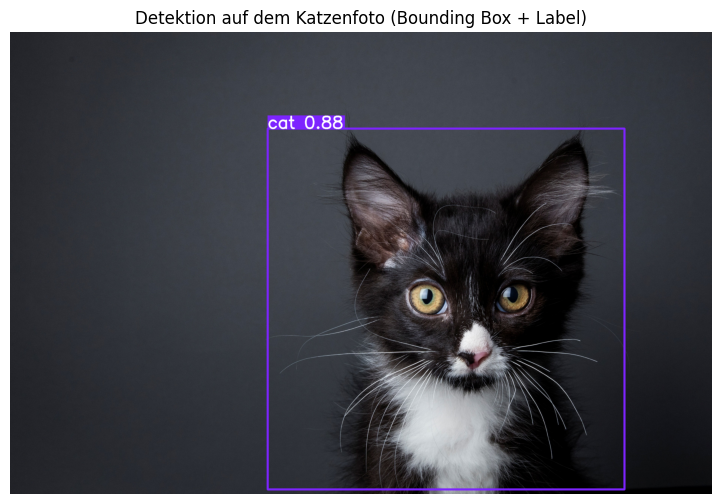

In [30]:
annotated_bgr = result_image.plot()
annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,6))
plt.imshow(annotated_rgb)
plt.axis("off")
plt.title("Detektion auf dem Katzenfoto (Bounding Box + Label)")
plt.show()

Perfekt! Das Modell hat tatsächlich sowohl das 'Objekt' richtig als Katze erkannt (mit
einer Konfidenz von 88% - nicht schlecht), als auch den dazugehörigen Bildbereich richtig
eingeschätzt. 

Zudem ist das Plotten des Outputs beinahe absurd einfach: der Output des Modells besitzt
bereits eine Methode `plot()`, die das Originalbild und die Annotationen (detektierten 
Bounding Boxes) für uns übereinanderlegt. Wir müssen alles nur wieder in RGB-Codierung
bringen und mit matplotlib.pyplot plotten - fertig.

Intereressant ist aber ein weiterer Unterschied zum Klassifikationsmodell:
der Trainingsdatensatz zum Detektionsmodell war hier offenbar ein anderer, da wir nicht
mehr die `egyptian cat` herausbekommen, sondern nur den Typ `cat`. Da drängt sich die
Frage auf: auf welche Objektklassen wurde das Detektionsmodell eigentlich trainiert?

Sehen wir uns das genauer an:

In [32]:
# Klassen-Namen aus dem Detection-Modell
class_names = det_model.names

print("Anzahl Klassen:", len(class_names))
print("Klassen:", list(class_names.values()))

Anzahl Klassen: 80
Klassen: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']


## Mehrere Objekte am Bild: Multi-Objekt Detektion

Wie wir sehen können, ist das Detektionsmodell auf deutlich weniger Klassen trainiert 
('nur' 80 Klassen, im Gegensatz zu den 1000 Klassen des Klassifikationsmodells). Die
Klassen sind allerdings sehr allgemein gehalten - z.B. gibt es hier nur eine Klasse `cat`
anstatt der vielen Klassen mit unterschiedlichen Katzenarten im Klassifikationsmodell -
sodass das vortrainierte Detektionsmodell dennoch ein mächtiges Werkzeug ist.

Wie mächtig sehen wir allerdings erst im Zusammenhang mit Multi-Object Bildern. Laden
wir also ein neues Bild, in dem sich nun mehrere Objekte befinden:

Image shape (H,W,C): (2000, 3006, 3)


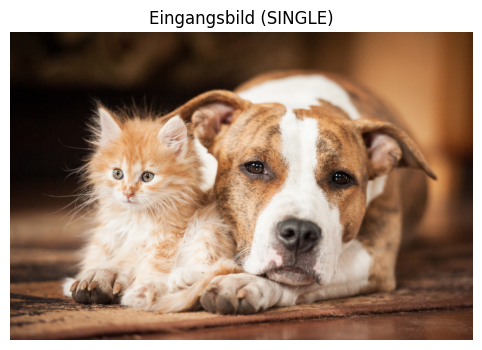

Typ: <class 'list'>
Anzahl Results: 1
Typ eines Elements: <class 'ultralytics.engine.results.Results'>


In [34]:
img_path = "/home/u88m52/projects/DIH-CV/images/multi-object/cat_dog.png"
img_bgr = cv2.imread(img_path)
print("Image shape (H,W,C):", img_bgr.shape)

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6,4))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Eingangsbild (SINGLE)")
plt.show()

Als nächstes übergeben wir das Bild als Input an unser Detektionsmodell. Hier erwarten
wir uns nun zwei Detektionen, d.h. zwei Klassenlabel, zwei Konfidenzen, und zwei
Bounding Boxes. Sehen wir nach, ob unsere Erwartung erfüllt wird:

In [39]:
result = det_model.predict(img_path, conf=0.25, verbose=False)
r_multi = result[0]

boxes_multi = r_multi.boxes

print("Anzahl Detektionen (MULTI):", len(boxes_multi))
print("xyxy shape:", boxes_multi.xyxy.shape)
print("conf shape:", boxes_multi.conf.shape)
print("cls  shape:", boxes_multi.cls.shape)

Anzahl Detektionen (MULTI): 2
xyxy shape: torch.Size([2, 4])
conf shape: torch.Size([2])
cls  shape: torch.Size([2])


Wir sehen: beim Multi-Object-Bild ist die Anzahl der Detektionen typischerweise deutlich größer.
In unserem Fall sehen wir hier überall `2` wo wir zuvor `1` hatten - das Modell hat unsere
zwei Objekte also tatsächlich erkannt.

Als nächstes visualisieren wir wieder die Detektionen im Bild, um die Ergebnisse zu prüfen:
Stimmen die Boxen? Gibt es False Positives oder verpasste Objekte?

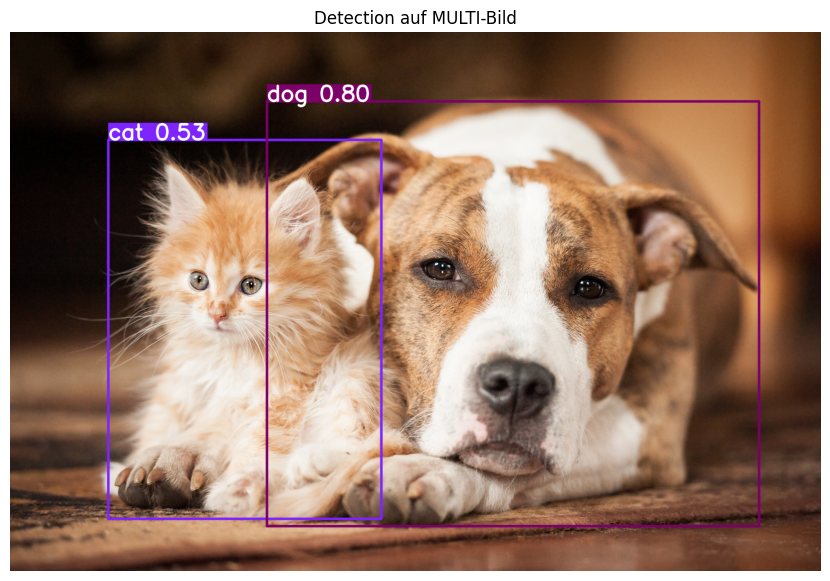

In [38]:
annotated2_bgr = r_multi.plot()
annotated2_rgb = cv2.cvtColor(annotated2_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,7))
plt.imshow(annotated2_rgb)
plt.axis("off")
plt.title("Detection auf MULTI-Bild")
plt.show()

## Die gewünschte Genauigkeit: der Konfidenz-Threshold

Perfekt! Unser Modell hat sowohl die Klassen, als auch ihren Bildbereich wieder richtig
erkannt. Die Konfidenz für die Klasse `cat` ist allerdings recht niedrig - unter
Umständen zu niedrig, falls wir in einer Anwendung darauf angewiesen wären, Katzen
tatsächlich verlässlich zu detektieren.

Das führt uns zu einer der 'Stellschrauben' beim Detektionsmodell: dem 
**Konfidenz-Threshold**. Der gibt einen Mindestwert für die 
Konfidenz an, der mindestens erreicht werden muss, damit das Modell das Objekt als die
entsprechende Klasse detektiert.

Nehmen wir an, wir wollen alle Objekte mit mindestens 60-prozentiger Konfidenz detektieren:

Detektionen mit conf=0.50: 1


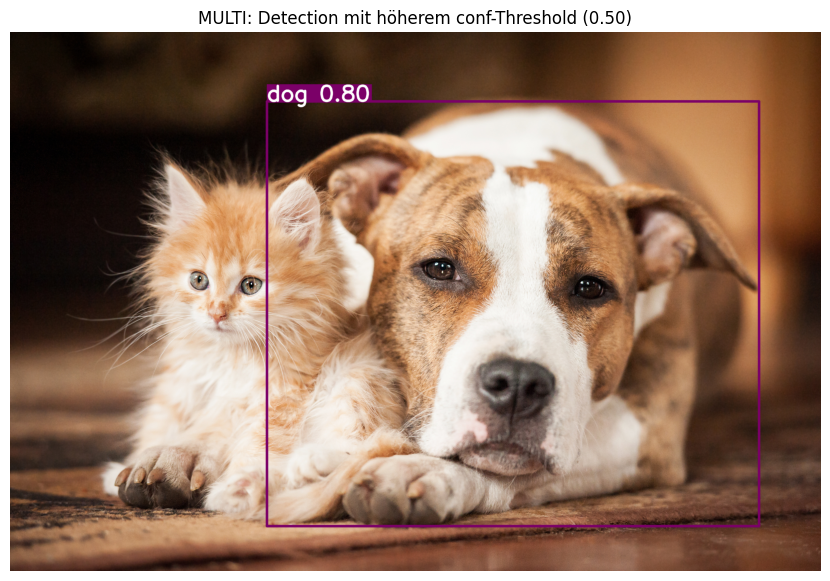

In [40]:
res_multi_strict = det_model.predict(img_path, conf=0.60, verbose=False)[0]
print("Detektionen mit conf=0.50:", len(res_multi_strict.boxes))

annot_bgr = res_multi_strict.plot()
annot_rgb = cv2.cvtColor(annot_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,7))
plt.imshow(annot_rgb)
plt.axis("off")
plt.title("MULTI: Detection mit höherem conf-Threshold (0.50)")
plt.show()

Wir sehen schon: plötzlich gibt uns das Modell nurmehr eine Klasse, `dog`, zurück! Beim
Hund ist es sich ziemlich sicher (80% Konfidenz), aber die Katze wurde ja nur mit 53%
Konfidenz erkannt - das ist uns zu wenig, daher gibt das Modell diese Klasse gar nicht
mehr mit aus! 

Sehen wir uns das noch bei ein paar anderen Beispielbildern an:

Detektionen mit conf=0.25: 2


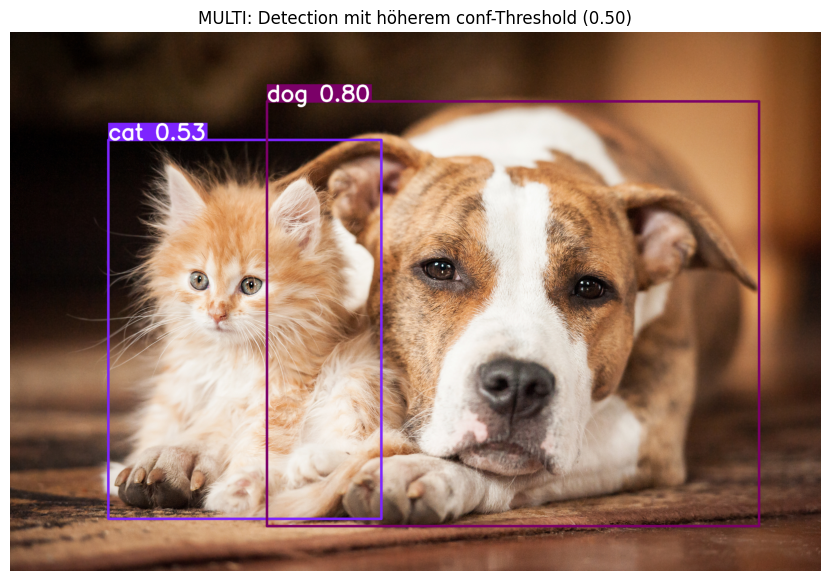

Detektionen mit conf=0.25: 4


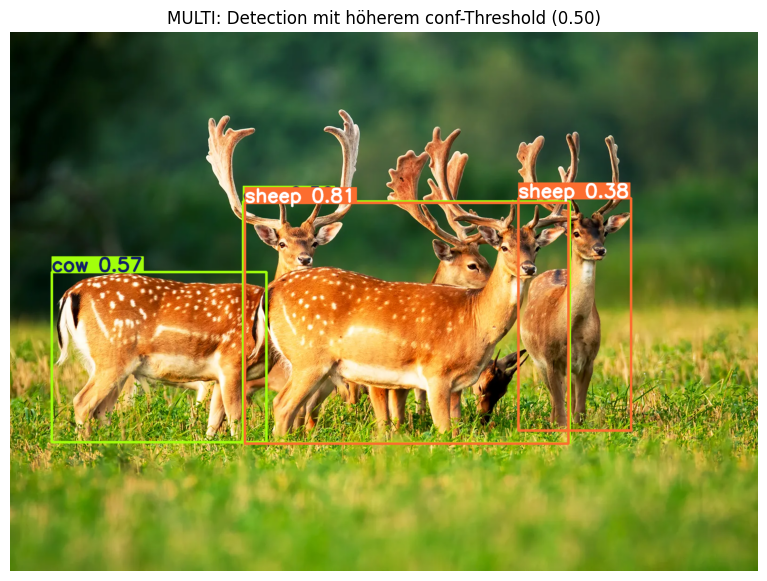

Detektionen mit conf=0.25: 6


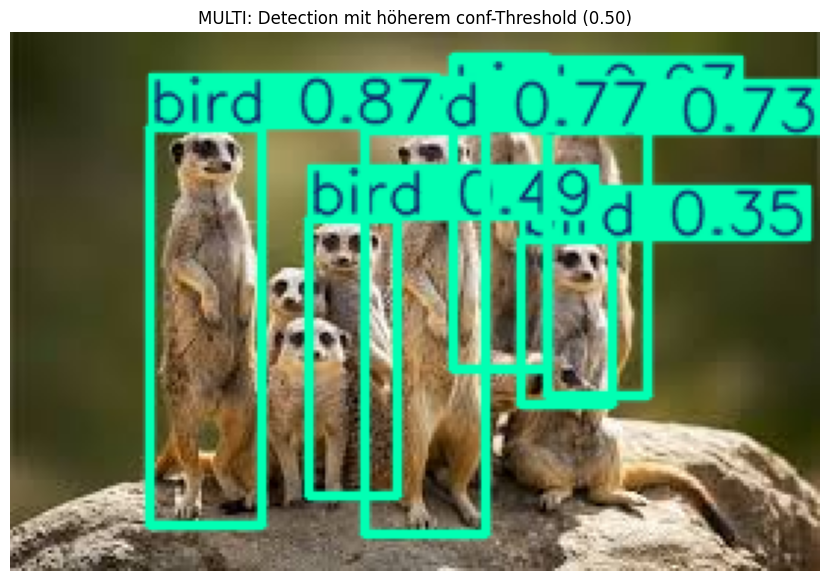

Detektionen mit conf=0.25: 3


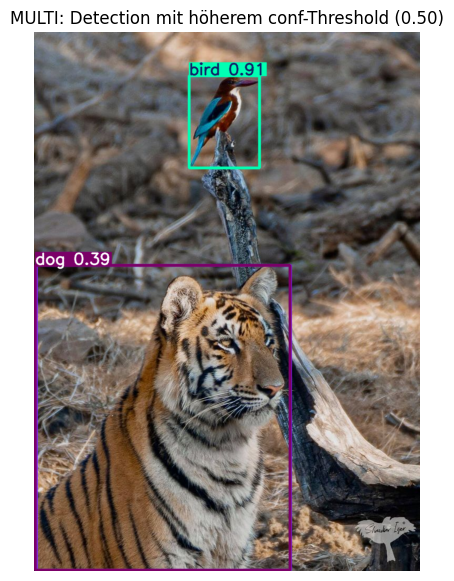

Detektionen mit conf=0.25: 8


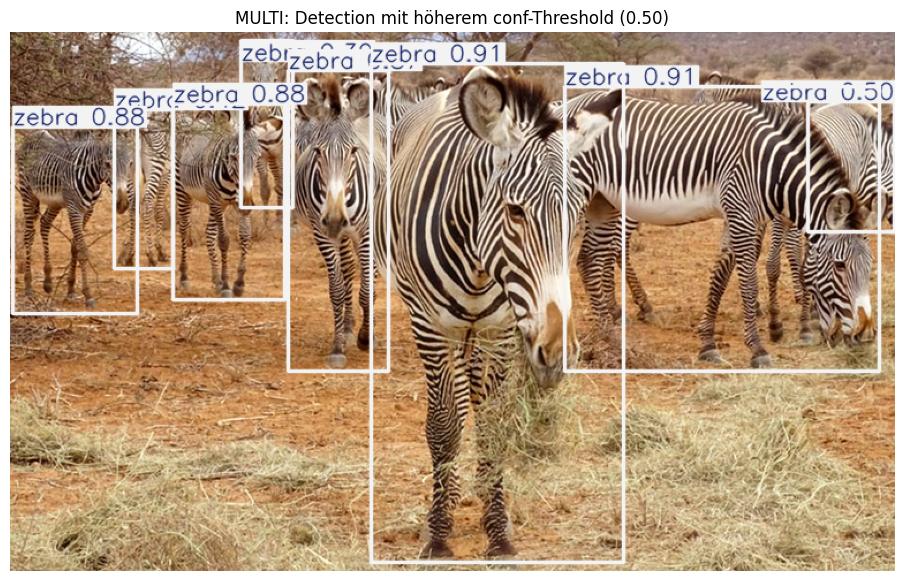

In [43]:
img_path = "/home/u88m52/projects/DIH-CV/images/multi-object"
results = det_model.predict(img_path, conf=0.25, verbose=False)

for result in results:
    print("Detektionen mit conf=0.25:", len(result.boxes))
    annot_bgr = result.plot()
    annot_rgb = cv2.cvtColor(annot_bgr, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12,7))
    plt.imshow(annot_rgb)
    plt.axis("off")
    plt.title("MULTI: Detection mit höherem conf-Threshold (0.50)")
    plt.show()

Wir sehen hier wieder ein ähnliches Problem, wie schon beim Klassifikationsmodell zuvor
bei den 'eigenartigen Tieren': Klassen, auf die das Modell nicht trainiert ist (z.B.
Erdmännchen) werden im Normalfall als eine Klasse erkannt, die vom Modell als 'ähnlich'
eingestuft wird - die Outputs können dann durchaus skurril werden (Tiger als `dog`,
Hirsche als `cow` oder `sheep`, etc.). Die verwendeten Trainingsdaten sind also sehr
relevant, falls man Objektdetektion auf sehr speziellen Klassen verwenden will!

## Zusammenfassend...

Damit haben wir jetzt den Kern von Object Detection abgedeckt:

- ein Detection-Modell (wieder von YOLO - dazu später mehr) laden
- eine Inferenz auf einzelnen Bildern / Ordnern durchlaufen lassen (Klassen + Boxes)
- die Inferenzen visualisieren und ausgeben
- den Konfidenz-Threshold entsprechend unserer Anforderungen ändern

In der nächsten Demo sehen wir uns an, wie die Objekterkennung noch genauer funktionieren
kann: via **Bildsegmentierung**.